In [105]:
from keras.utils import image_dataset_from_directory
import matplotlib.pyplot as plt
from keras.models import Sequential
from keras import layers
from keras.losses import SparseCategoricalCrossentropy
from keras.callbacks import EarlyStopping
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
from keras.applications import MobileNetV2
from keras.optimizers import Adam
from sklearn.metrics import classification_report

In [106]:
import matplotlib as mpl
print("axes.grid = ", mpl.rcParams['axes.grid'])
mpl.rcParams['axes.grid'] = False

axes.grid =  False


Ucitavanje podataka

In [107]:
Xtrain, Xval = image_dataset_from_directory('Human Action Recognition/train_sorted', subset = 'both', validation_split = 0.2, image_size = (128, 128), batch_size = 64, shuffle = True, seed = 42)

Found 8000 files belonging to 10 classes.
Using 6400 files for training.
Using 1600 files for validation.


In [108]:
klase = Xtrain.class_names
brklasa = len(klase)
print(f'Dataset ima sledece klase: {klase}')

Dataset ima sledece klase: ['clapping', 'cycling', 'dancing', 'eating', 'fighting', 'hugging', 'laughing', 'running', 'sleeping', 'using_laptop']


Found 8000 files belonging to 10 classes.


([<matplotlib.axis.XTick at 0x121633c8da0>,
 [Text(0, 0, 'clapping'),
  Text(1, 0, 'cycling'),
  Text(2, 0, 'dancing'),
  Text(3, 0, 'eating'),
  Text(4, 0, 'fighting'),
  Text(5, 0, 'hugging'),
  Text(6, 0, 'laughing'),
  Text(7, 0, 'running'),
  Text(8, 0, 'sleeping'),
  Text(9, 0, 'using_laptop')])

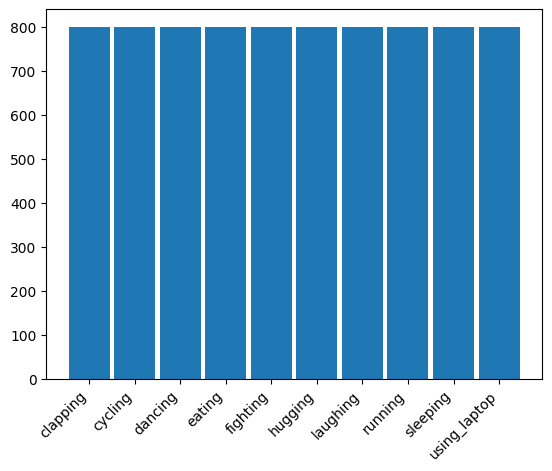

In [109]:
X = image_dataset_from_directory("Human Action Recognition/train_sorted", image_size = (128,128), shuffle = False)

Y = np.array([])
for _, label in X:
    Y = np.append(Y, label.numpy())
plt.hist(Y, bins = np.arange(brklasa + 1) - 0.5, rwidth = 0.9)
plt.xticks(range(brklasa), klase, rotation = 45, ha = 'right')

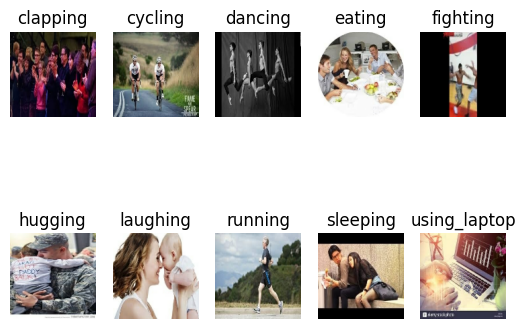

In [110]:
picked = [None]*brklasa

for imgs, labs in X:
    for img, lab in zip(imgs, labs):
        if picked[lab] is None:
            picked[lab] = img
    if all(p is not None for p in picked):
        break

for i, img in enumerate(picked):
    plt.subplot(2,5,i+1)
    plt.imshow(img.numpy().astype("uint8"))
    plt.title(klase[i])
    plt.axis("off")
plt.show()

Prikaz podataka

In [111]:
img, lab = next(iter(Xtrain))

Data Augmentation

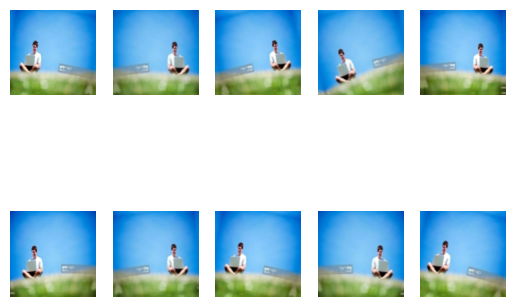

In [112]:
data_aug = Sequential([
    layers.Input((128, 128, 3)),
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.05),
    layers.RandomContrast(0.1),   # novo
])

plt.figure()
for i in range(1,11):
    img_aug = data_aug(img)
    plt.subplot(2, 5, i)
    plt.imshow(img_aug[1].numpy().astype("uint8"))
    plt.axis('off')
plt.show()


Transfer znanja

In [113]:
cnn_deo = MobileNetV2(input_shape = (128, 128, 3), include_top = False, weights = 'imagenet')
cnn_deo.trainable = False

model = Sequential([layers.Input(shape=(128, 128, 3)), data_aug, layers.Rescaling(1./127.5, offset = -1),
                    cnn_deo, layers.GlobalAveragePooling2D(), layers.Dense(64, activation = 'relu'),
                    layers.Dropout(0.3), layers.Dense(32, activation = 'relu'), layers.Dropout(0.3), layers.Dense(brklasa, activation = 'softmax')])

model.compile('adam', loss = SparseCategoricalCrossentropy(), metrics = ['accuracy'])

model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_12 (Sequential)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_6 (Rescaling)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_6      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 64)             │        81,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,342,378 (8.94 MB)

 Trainable params: 84,394 (329.66 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

Treniranje FC dela

Epoch 14: early stopping
Restoring model weights from the end of the best epoch: 9.


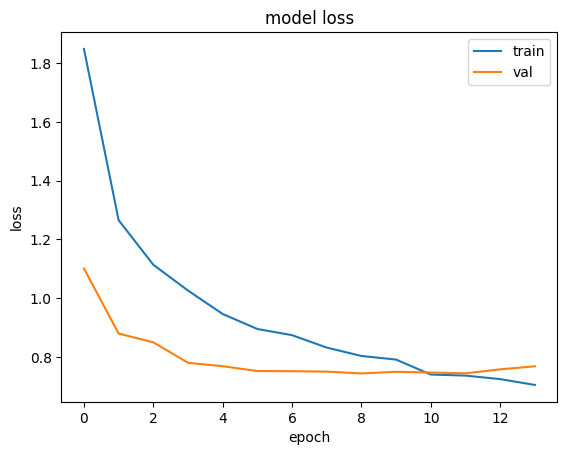

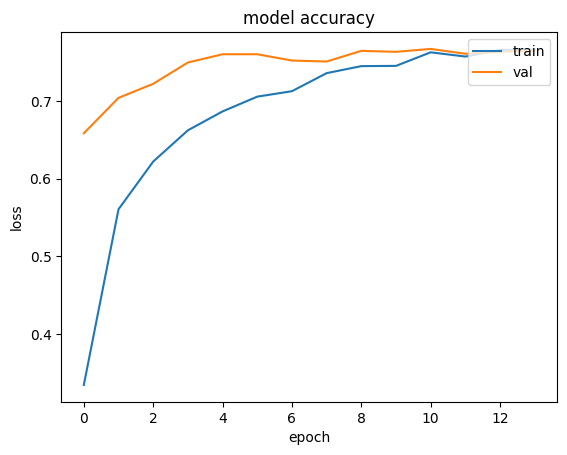

In [114]:
es = EarlyStopping(monitor='val_loss', patience=5, verbose=1, mode='min', restore_best_weights=True)

hist2 = model.fit(Xtrain, epochs = 30, verbose = 0, validation_data = Xval, callbacks=[es])

plt.figure()
plt.plot(hist2.history['loss'])
plt.plot(hist2.history['val_loss'])
plt.title('model loss')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend(['train', 'val'], loc='upper right')
plt.show()

plt.figure()
plt.plot(hist2.history['accuracy'])
plt.plot(hist2.history['val_accuracy'])
plt.title('model accuracy')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend(['train', 'val'], loc='upper right')
plt.show()

In [115]:
Ytrainpred = np.array([])
Ytrain = np.array([])

for img,lab in Xtrain:
    Ytrain = np.append(Ytrain, lab.numpy())
    Ytrainpred = np.append(Ytrainpred, np.argmax(model.predict(img, verbose = 0), axis = 1))

cm = confusion_matrix(Ytrain, Ytrainpred)
# ConfusionMatrixDisplay(cm, display_labels = klase).plot(xticks_rotation = 75)
print('Tacnost je ', accuracy_score(Ytrain, Ytrainpred))

cr = classification_report(Ytrain, Ytrainpred, target_names = klase)
print(cr)

Tacnost je  0.8196875
              precision    recall  f1-score   support

    clapping       0.88      0.64      0.74       661
     cycling       0.95      0.96      0.96       654
     dancing       0.73      0.83      0.78       634
      eating       0.91      0.90      0.90       626
    fighting       0.86      0.64      0.73       638
     hugging       0.68      0.83      0.74       639
    laughing       0.82      0.80      0.81       626
     running       0.84      0.80      0.82       636
    sleeping       0.87      0.87      0.87       647
using_laptop       0.75      0.92      0.82       639

    accuracy                           0.82      6400
   macro avg       0.83      0.82      0.82      6400
weighted avg       0.83      0.82      0.82      6400



Tacnost je  0.765


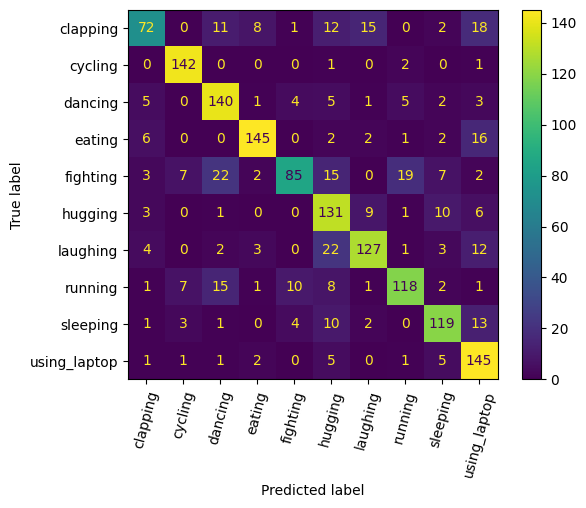

In [116]:
Yvalpred = np.array([])
Yval = np.array([])
for img,lab in Xval:
    Yval = np.append(Yval, lab.numpy())
    Yvalpred = np.append(Yvalpred, np.argmax(model.predict(img, verbose = 0), axis = 1))

cm = confusion_matrix(Yval, Yvalpred)
ConfusionMatrixDisplay(cm, display_labels = klase).plot(xticks_rotation = 75)
print('Tacnost je ', accuracy_score(Yval, Yvalpred))

Fine Tuning - FC deo istreniran, dotreniramo CNN

In [117]:
for layer in cnn_deo.layers:
    layer.trainable = True
for layer in cnn_deo.layers:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False
        
tuningopt = Adam(1e-5)

es2 = EarlyStopping(monitor='val_accuracy', patience=5, verbose=1, mode='max', restore_best_weights=True)

model.compile(optimizer = tuningopt, loss = SparseCategoricalCrossentropy(), metrics = ['accuracy'])

hist3 = model.fit(Xtrain, epochs = 20, verbose = 0, validation_data = Xval, callbacks = [es2])

Epoch 15: early stopping
Restoring model weights from the end of the best epoch: 10.


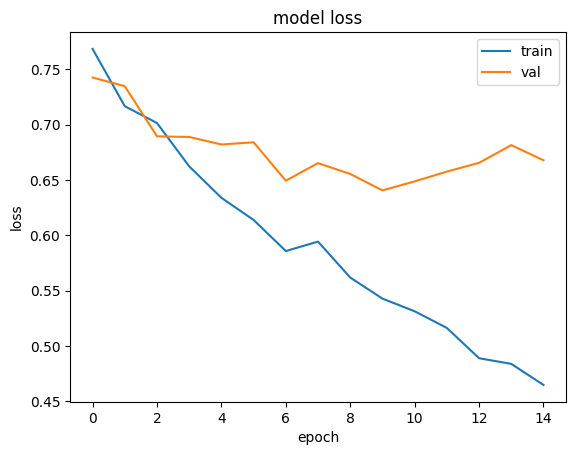

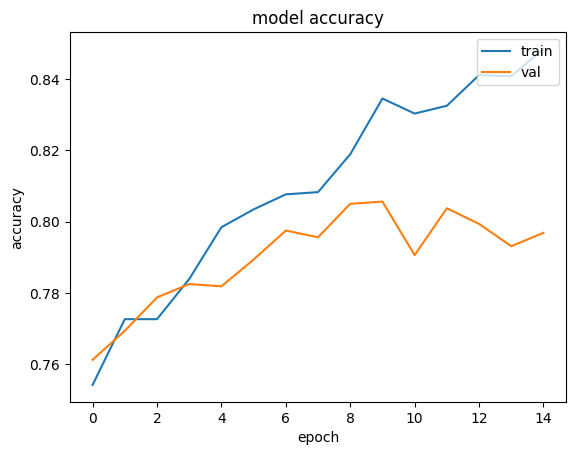

In [118]:
plt.figure()
plt.plot(hist3.history['loss'])
plt.plot(hist3.history['val_loss'])
plt.title('model loss')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend(['train', 'val'], loc='upper right')
plt.show()

plt.figure()
plt.plot(hist3.history['accuracy'])
plt.plot(hist3.history['val_accuracy'])
plt.title('model accuracy')
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.legend(['train', 'val'], loc='upper right')
plt.show()

Tacnost je  0.87859375
              precision    recall  f1-score   support

    clapping       0.95      0.73      0.83       661
     cycling       0.93      0.99      0.96       654
     dancing       0.80      0.89      0.84       634
      eating       0.93      0.96      0.94       626
    fighting       0.88      0.75      0.81       638
     hugging       0.80      0.90      0.85       639
    laughing       0.84      0.89      0.86       626
     running       0.91      0.85      0.88       636
    sleeping       0.91      0.91      0.91       647
using_laptop       0.88      0.92      0.90       639

    accuracy                           0.88      6400
   macro avg       0.88      0.88      0.88      6400
weighted avg       0.88      0.88      0.88      6400



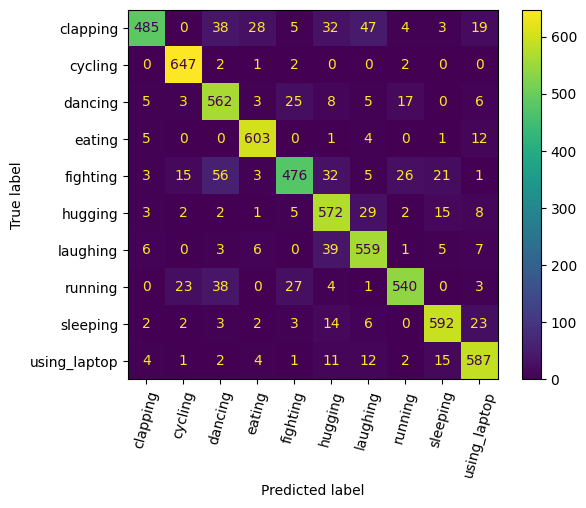

In [119]:
Ytrainpred = np.array([])
Ytrain = np.array([])

for img,lab in Xtrain:
    Ytrain = np.append(Ytrain, lab.numpy())
    Ytrainpred = np.append(Ytrainpred, np.argmax(model.predict(img, verbose = 0), axis = 1))

cm = confusion_matrix(Ytrain, Ytrainpred)
ConfusionMatrixDisplay(cm, display_labels = klase).plot(xticks_rotation = 75)
print('Tacnost je ', accuracy_score(Ytrain, Ytrainpred))

cr = classification_report(Ytrain, Ytrainpred, target_names = klase)
print(cr)

Na val skupu

Tacnost je  0.805625
              precision    recall  f1-score   support

    clapping       0.79      0.58      0.67       139
     cycling       0.87      0.99      0.92       146
     dancing       0.78      0.85      0.81       166
      eating       0.90      0.90      0.90       174
    fighting       0.83      0.62      0.71       162
     hugging       0.70      0.84      0.76       161
    laughing       0.78      0.80      0.79       174
     running       0.85      0.75      0.80       164
    sleeping       0.78      0.86      0.82       153
using_laptop       0.81      0.84      0.83       161

    accuracy                           0.81      1600
   macro avg       0.81      0.80      0.80      1600
weighted avg       0.81      0.81      0.80      1600



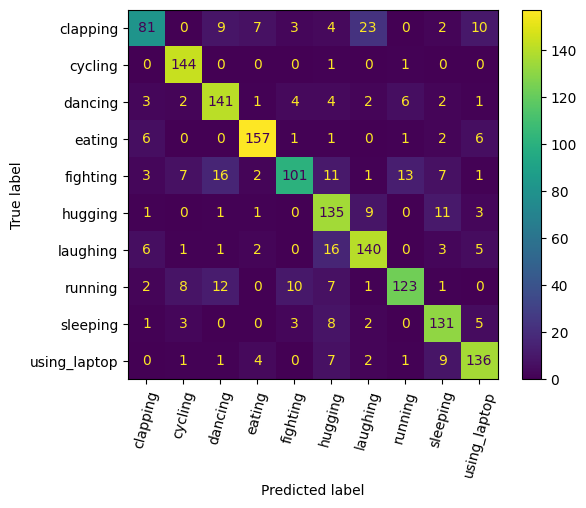

In [120]:
Yvalpred = np.array([])
Yval = np.array([])
for img,lab in Xval:
    Yval = np.append(Yval, lab.numpy())
    Yvalpred = np.append(Yvalpred, np.argmax(model.predict(img, verbose = 0), axis = 1))

cm = confusion_matrix(Yval, Yvalpred)
ConfusionMatrixDisplay(cm, display_labels = klase).plot(xticks_rotation = 75)
print('Tacnost je ', accuracy_score(Yval, Yvalpred))

from sklearn.metrics import classification_report

cr = classification_report(Yval, Yvalpred, target_names = klase)
print(cr)

Found 406 files belonging to 10 classes.


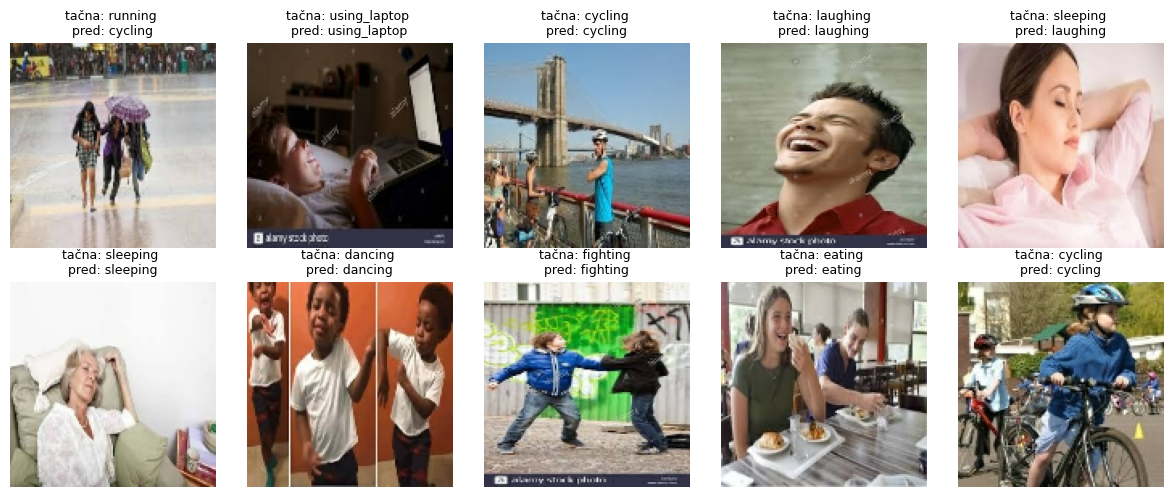

In [121]:
Xtest = image_dataset_from_directory('Human Action Recognition/test_sorted_short', image_size = (128,128), seed = 42, batch_size = 32)

imgs, labs = next(iter(Xtest))
pred = np.argmax(model.predict(imgs, verbose=0), axis=1)

plt.figure(figsize=(12,5))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(imgs[i].numpy().astype("uint8"))
    plt.title(f"tačna: {klase[int(labs[i])]} \npred: {klase[pred[i]]}", fontsize=9)
    plt.axis("off")
plt.tight_layout()
plt.show()


Na test skupu

Tacnost je  0.8078817733990148
              precision    recall  f1-score   support

    clapping       0.89      0.57      0.70        42
     cycling       0.95      1.00      0.98        40
     dancing       0.72      0.72      0.72        40
      eating       1.00      0.98      0.99        42
    fighting       0.74      0.70      0.72        40
     hugging       0.69      0.90      0.78        40
    laughing       0.72      0.78      0.75        40
     running       0.83      0.72      0.77        40
    sleeping       0.82      0.86      0.84        42
using_laptop       0.77      0.85      0.81        40

    accuracy                           0.81       406
   macro avg       0.81      0.81      0.81       406
weighted avg       0.81      0.81      0.81       406



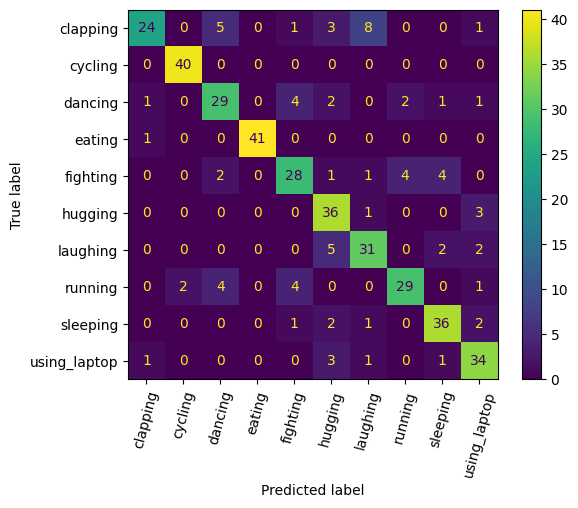

In [122]:
Ytestpred = np.array([])
Ytest = np.array([])
for img,lab in Xtest:
    Ytest = np.append(Ytest, lab.numpy())
    Ytestpred = np.append(Ytestpred, np.argmax(model.predict(img, verbose = 0), axis = 1))

cm = confusion_matrix(Ytest, Ytestpred)
ConfusionMatrixDisplay(cm, display_labels = klase).plot(xticks_rotation = 75)
print('Tacnost je ', accuracy_score(Ytest, Ytestpred))

cr = classification_report(Ytest, Ytestpred, target_names = klase)
print(cr)